# Notebook 1: data preparation and data engineering

**Goal.** Turn the raw Excel files into clean, small, analysis-ready tables. Later notebooks (analysis, proxy, history matching, forecast) read the files from `data_after_engineering/` and never touch the raw Excel again.

**Why this notebook exists.** The raw files are hard to use as they are:

| Raw file | Problem | What we do here |
|---|---|---|
| `01` | Parameters sit in a table with text labels (`Case 1`) | Add a numeric `case_id`, a `split` label, a CV fold and scaled copies |
| `02` | Six wide tabs, 11,096 dates, 98% empty cells, one extra column that is the observed history | Pivot to a tidy long table, and cut a second table on the 41 quarterly dates |
| `03`-`08` | 100 sheets x 90,365 rows, 330 MB per file, 20 s to read one sheet, missing values written as `-999.25` | Read once in parallel, clean, keep only what changes between cases |
| `09` | Dates are text, tab `Case 1` is shorter than the others | Build one clean list of the 80 forecast dates |

**Outputs.** Everything goes to `data_after_engineering/` (list at the end). Small tables are CSV. The big grid array is NumPy, because a CSV of it would be several hundred MB.

**How to run.** Run all cells from the top. Reading the grid takes about 15 minutes the first time (measured: 16 min with 6 workers). After that the result is cached in `data_after_engineering/`, and a re-run takes under a minute. The folder `data_after_engineering/cache/` is part of that cache: if you delete it, the next run reads the grid again. Set `REBUILD_GRID = True` to force a new read.

**Marking.** *Verified* means the notebook checks it with an `assert` or a printed number.

## 0. Setup

In [1]:
import sys, time, warnings
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl

warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.6g}")

# Paths. The notebook sits in the project root (next to dataset_ori/ and data_after_engineering/).
HERE = Path.cwd()
ROOT = HERE if (HERE / "dataset_ori").exists() else HERE.parent
DATA = ROOT / "dataset_ori"
OUT = ROOT / "data_after_engineering"
CACHE = OUT / "cache"
OUT.mkdir(parents=True, exist_ok=True)
CACHE.mkdir(exist_ok=True)
sys.path.insert(0, str(ROOT / "src"))
import grid_loader as gl          # helper module src/grid_loader.py: reads one grid sheet (needed for multiprocessing)

REBUILD_GRID = False              # True = read the 100 grid sheets again (about 15 min)
N_WORKERS = max(1, min(6, (__import__("os").cpu_count() or 2) - 2))
HIST_START = pd.Timestamp("1998-01-01")   # day 0 of the time axis
NA = gl.NA_VALUE                           # -999.25 = missing value in the grid sheets
PARAMS = ["fault_trans", "poro_mult", "perm_mult", "aquifer_pv"]
CHECKS = []                                # list of (check, result) shown at the end

def check(name, ok, detail=""):
    """Record a check, and stop if it fails."""
    CHECKS.append({"check": name, "ok": bool(ok), "detail": detail})
    assert ok, f"CHECK FAILED: {name} {detail}"

def save_csv(df, path, index=False, **kw):
    """Write a CSV with every float rounded to 15 significant digits.
    Excel keeps only 15 digits, and long digit strings (17 digits, e.g. 1496.1765136689814) are
    shown with a 'text' marker in some Excel routes. Rounding to 15 digits changes a value by at most
    5e-16 (relative), far below any real precision in this data. The .npy/.npz files keep full precision."""
    out = df.copy()
    for c in out.columns:
        if pd.api.types.is_float_dtype(out[c]):
            out[c] = out[c].map("{:.15g}".format).astype(float)
    out.to_csv(path, index=index, **kw)

print("project root :", ROOT)
print("output folder:", OUT)
print("workers      :", N_WORKERS)

project root : c:\Users\Yi Siang\Documents\UM\dwc_team_what_repo
output folder: c:\Users\Yi Siang\Documents\UM\dwc_team_what_repo\data_after_engineering
workers      : 6


## 1. Case table: the 4 parameters, the split and the folds (file `01`)

**What we do**

1. Read tab `Uncertainty Values` (100 rows, one per case).
2. Make a numeric `case_id` (1 to 100). This is the key for all other tables.
3. Give each case its **split** from the file it sits in: `03`-`06` = train (cases 1-70), `07` = validation (71-85), `08` = test (86-100). We keep the organiser's split. We do not shuffle.
4. Add a `cv_fold` (0-4) for the 85 train + validation cases. It is optional. It lets us tune with cross-validation, which is steadier than 15 validation cases alone. Test cases get `-1` and stay locked.
5. Add min-max scaled copies of the parameters (`*_s`, 0 to 1). The bounds come from the **train** cases only, so no information leaks from validation or test.

In [2]:
F01 = DATA / "01 Introduction.xlsx"
raw01 = pd.read_excel(F01, sheet_name="Uncertainty Values")
cases = raw01.rename(columns={
    "Item": "item",
    "Fault Transmissibility": "fault_trans",
    "Porosity Multiplier": "poro_mult",
    "Permeability Multiplier": "perm_mult",
    "Aquifer Pore Volume": "aquifer_pv",
})
cases["case_id"] = cases["item"].str.extract(r"(\d+)", expand=False).astype(int)
cases = cases.sort_values("case_id").reset_index(drop=True)

check("01: 100 cases, ids 1..100, no duplicates",
      len(cases) == 100 and list(cases.case_id) == list(range(1, 101)))
check("01: no missing parameter values", cases[PARAMS].notna().all().all())

# Which file (and sheet) holds each grid case? Read only the sheet names (fast).
case_to_file = {}
for f in sorted(DATA.glob("0[3-8]*.xlsx")):
    wb = openpyxl.load_workbook(f, read_only=True)
    for s in wb.sheetnames:
        cid = int(s.split()[-1])
        assert cid not in case_to_file, f"case {cid} appears twice"
        case_to_file[cid] = (f, s)
    wb.close()
check("03-08: sheets cover cases 1..100 exactly once", sorted(case_to_file) == list(range(1, 101)))

SPLIT_BY_PREFIX = {"03": "train", "04": "train", "05": "train", "06": "train",
                   "07": "validation", "08": "test"}
cases["source_file"] = cases.case_id.map(lambda c: case_to_file[c][0].name)
cases["split"] = cases.source_file.str[:2].map(SPLIT_BY_PREFIX)

sizes = cases.split.value_counts().to_dict()
check("split sizes are 70 / 15 / 15", sizes == {"train": 70, "validation": 15, "test": 15}, str(sizes))
check("split follows case-id ranges (train 1-70, validation 71-85, test 86-100)",
      (cases.loc[cases.split == "train", "case_id"].between(1, 70).all()
       and cases.loc[cases.split == "validation", "case_id"].between(71, 85).all()
       and cases.loc[cases.split == "test", "case_id"].between(86, 100).all()))

# Cross-validation folds for train + validation (85 cases). Test stays at -1.
rng = np.random.default_rng(42)
dev_ids = cases.loc[cases.split != "test", "case_id"].to_numpy()
cases["cv_fold"] = -1
for n, cid in enumerate(rng.permutation(dev_ids)):
    cases.loc[cases.case_id == cid, "cv_fold"] = n % 5

# Scaled copies. Bounds come from the TRAIN cases only.
train = cases[cases.split == "train"]
bounds = pd.DataFrame({"train_min": train[PARAMS].min(), "train_max": train[PARAMS].max()})
for p in PARAMS:
    lo, hi = bounds.loc[p]
    cases[p + "_s"] = (cases[p] - lo) / (hi - lo)
bounds.index.name = "parameter"

cases = cases[["case_id", "item", "split", "cv_fold", "source_file"] + PARAMS + [p + "_s" for p in PARAMS]]
save_csv(cases, OUT / "cases.csv")
save_csv(bounds, OUT / "param_bounds.csv", index=True)

print(cases.groupby("split")[PARAMS].agg(["min", "max"]).T.to_string())
print()
print("cases per fold:", cases.cv_fold.value_counts().sort_index().to_dict())
cases.head()

split                test     train  validation
fault_trans min 0.0519202 0.0507904   0.0501093
            max  0.149907   0.14995    0.138613
poro_mult   min  0.809766  0.801219    0.836516
            max   1.47912   1.49403     1.47236
perm_mult   min  0.520527  0.537516    0.771641
            max   9.65466   9.50197     9.78455
aquifer_pv  min   57.3992   53.9529     56.2642
            max    175.52   199.835     198.826

cases per fold: {-1: 15, 0: 17, 1: 17, 2: 17, 3: 17, 4: 17}


,case_id,item,split,cv_fold,source_file,fault_trans,poro_mult,perm_mult,aquifer_pv,fault_trans_s,poro_mult_s,perm_mult_s,aquifer_pv_s
0,1,Case 1,train,1,03 Train Cases 1.xlsx,0.0523505,1.08231,3.04735,68.3523,0.0157332,0.405723,0.279976,0.0987056
1,2,Case 2,train,3,03 Train Cases 1.xlsx,0.0894555,1.22939,6.35407,119.991,0.389927,0.618024,0.648846,0.452684
2,3,Case 3,train,2,03 Train Cases 1.xlsx,0.127971,0.885781,1.48099,198.958,0.778346,0.122057,0.105246,0.993988
3,4,Case 4,train,2,03 Train Cases 1.xlsx,0.145503,1.36414,8.6025,158.107,0.955154,0.812515,0.899663,0.713959
4,5,Case 5,train,0,03 Train Cases 1.xlsx,0.1112,0.949402,5.39815,136.151,0.609216,0.213887,0.542212,0.563458


In [3]:
# Do validation and test cases sit inside the range of the train cases?
rng_width = bounds.train_max - bounds.train_min
rows = []
for sp in ["validation", "test"]:
    d = cases[cases.split == sp]
    for p in PARAMS:
        lo, hi = bounds.loc[p]
        for cid, v in zip(d.case_id, d[p]):
            if v < lo or v > hi:
                rows.append({"split": sp, "case_id": cid, "parameter": p, "value": v,
                             "train range": f"{lo:.4g} to {hi:.4g}",
                             "outside by (share of train range)": (lo - v) / rng_width[p] if v < lo else (v - hi) / rng_width[p]})
outside = pd.DataFrame(rows)
print(f"{len(outside)} parameter values of the 30 validation/test cases lie outside the train range")
check("validation/test parameters are at most 5% of the train range outside it (nearly interpolation)",
      outside.empty or outside["outside by (share of train range)"].max() < 0.05,
      f"max {outside['outside by (share of train range)'].max():.3f}" if len(outside) else "")

# Are the 4 parameters independent of each other? (a space-filling design should give small correlations)
corr = cases[PARAMS].corr(method="spearman")
print("largest off-diagonal |Spearman| between parameters:",
      round(float(corr.abs().where(~np.eye(4, dtype=bool)).max().max()), 3))
outside

5 parameter values of the 30 validation/test cases lie outside the train range
largest off-diagonal |Spearman| between parameters: 0.172


,split,case_id,parameter,value,train range,outside by (share of train range)
0,validation,82,fault_trans,0.0501093,0.05079 to 0.15,0.00686944
1,validation,75,perm_mult,9.5368,0.5375 to 9.502,0.00388532
2,validation,82,perm_mult,9.78455,0.5375 to 9.502,0.0315224
3,test,87,perm_mult,0.520527,0.5375 to 9.502,0.00189523
4,test,98,perm_mult,9.65466,0.5375 to 9.502,0.0170333


## 2. Observed history (file `02`)

The real field history has two sources inside `02`:

* tab `Field Production`: rates for 41 quarterly dates, and the water injection rate;
* column `RAMP_History` in the six curve tabs: the **cumulative** values (and the same rates).

We join them into one table with 41 rows. This table is the target of history matching.

First we read all six curve tabs. Each tab has 3 header rows (plot labels, column names, units).

In [4]:
F02 = DATA / "02 Field Production.xlsx"

CURVE_TABS = {                      # name used here -> tab name in the file
    "gas_cum":    "Gas production cumulative",
    "oil_cum":    "Oil production cumulative",
    "water_cum":  "Water production cumulative",
    "gas_rate":   "Gas production rate",
    "oil_rate":   "Oil production rate",
    "water_rate": "Water production rate",
}

def read_curve_tab(sheet):
    """Wide table: index = Date, columns = Case_1..Case_100 and RAMP_History."""
    d = pd.read_excel(F02, sheet_name=sheet, header=1)    # row 2 holds the column names
    units = d.iloc[0].drop("Date")                         # row 3 holds the unit labels
    d = d.iloc[1:].copy()
    d["Date"] = pd.to_datetime(d["Date"])
    d = d.set_index("Date").apply(pd.to_numeric)
    return d, units

t0 = time.time()
tabs, units = {}, {}
for key, sheet in CURVE_TABS.items():
    tabs[key], u = read_curve_tab(sheet)
    units[key] = u.iloc[0]
print(f"read 6 tabs in {time.time() - t0:.0f} s; each tab: {tabs['oil_cum'].shape[0]:,} dates x {tabs['oil_cum'].shape[1]} columns")
print(pd.Series(units).to_string())

check("02: the six tabs have the same dates", all(tabs[k].index.equals(tabs["oil_cum"].index) for k in tabs))
check("02: the six tabs have the same columns", all(list(tabs[k].columns) == list(tabs["oil_cum"].columns) for k in tabs))
check("02: 100 case columns + RAMP_History",
      list(tabs["oil_cum"].columns) == [f"Case_{i}" for i in range(1, 101)] + ["RAMP_History"])
check("02: the empty-cell pattern is the same in all six tabs",
      all(tabs[k].notna().equals(tabs["oil_cum"].notna()) for k in tabs))
print(f"\nshare of empty cells: {tabs['oil_cum'].isna().mean().mean():.1%}")

read 6 tabs in 40 s; each tab: 11,096 dates x 101 columns
gas_cum        Gas production cumulative [MSCF]
oil_cum         Oil production cumulative [STB]
water_cum     Water production cumulative [STB]
gas_rate           Gas production rate [MSCF/d]
oil_rate            Oil production rate [STB/d]
water_rate        Water production rate [STB/d]

share of empty cells: 98.5%


In [5]:
# --- Observed history: rates from tab "Field Production", cumulative from column RAMP_History
fp = pd.read_excel(F02, sheet_name="Field Production")
check("history: Identifier is always 'Field' (field-level data)", (fp["Identifier"] == "Field").all())
fp = fp.rename(columns={
    "Date": "date",
    "Oil production rate (STB/d)": "oil_rate",
    "Gas production rate (MSCF/d)": "gas_rate",
    "Water production rate (STB/d)": "water_rate",
    "Water injection rate (STB/d)": "water_inj_rate",
}).drop(columns="Identifier")

hist_cum = pd.concat({k: tabs[k]["RAMP_History"].dropna() for k in ["gas_cum", "oil_cum", "water_cum"]}, axis=1)
hist_cum.index.name = "date"
history = fp.merge(hist_cum.reset_index(), on="date", how="left", validate="one_to_one")

check("history: 41 quarterly rows from 1998-01-01 to 2008-01-01",
      len(history) == 41 and history.date.iloc[0] == HIST_START and history.date.iloc[-1] == pd.Timestamp("2008-01-01"))
check("history: cumulative values found for every date", history[["gas_cum", "oil_cum", "water_cum"]].notna().all().all())
check("history: RAMP_History rates in the curve tabs equal the 'Field Production' rates",
      all(np.allclose(tabs[f"{q}_rate"]["RAMP_History"].dropna().to_numpy(), history[f"{q}_rate"].to_numpy())
          for q in ["gas", "oil", "water"]))

history["t_days"] = (history.date - HIST_START).dt.days.astype(float)

def add_avg_rates(df, group=None):
    """Average rate over the period that ENDS on each date = change in cumulative / days.
    Both history and cases give a cumulative that follows one convention, so this rate is comparable."""
    g = df.groupby(group) if group else df
    for q in ["gas", "oil", "water"]:
        dcum = g[f"{q}_cum"].diff()
        dt = g["t_days"].diff()
        df[f"{q}_rate_avg"] = dcum / dt
    return df

history = add_avg_rates(history)
history = history[["date", "t_days", "gas_cum", "oil_cum", "water_cum",
                   "gas_rate", "oil_rate", "water_rate",
                   "gas_rate_avg", "oil_rate_avg", "water_rate_avg", "water_inj_rate"]]
save_csv(history, OUT / "history_observed.csv")
history.iloc[[0, 1, 4, 5, 20, 39, 40]]

,date,t_days,gas_cum,oil_cum,water_cum,gas_rate,oil_rate,water_rate,gas_rate_avg,oil_rate_avg,water_rate_avg,water_inj_rate
0,1998-01-01,0,0,0,0,0,0,0,NaN,NaN,NaN,0
1,1998-04-01,90,0,0,0,0,0,0,0,0,0,0
4,1999-01-01,365,"518,325",1.42671e+06,0,"5,549.46","15,275.2",0,"5,633.97","15,507.8",0,"12,098.5"
5,1999-04-01,455,1.01778e+06,2.80148e+06,0,"5,609.43","15,440.2",0.0590949,"5,549.46","15,275.2",0,"11,879.9"
20,2003-01-01,"1,826",8.48058e+06,2.33432e+07,2.08017e+06,"4,768.93","13,126.7","3,776.1","5,050.19","13,900.9","3,504.18","11,834.8"
39,2007-10-01,"3,560",1.37672e+07,3.78956e+07,1.20985e+07,"1,905.58","5,246.8","7,782.27","1,973.9","5,433.26","7,615.67","9,336.73"
40,2008-01-01,"3,652",1.39425e+07,3.83783e+07,1.28144e+07,"1,838.96","5,066.68","7,926.36","1,905.58","5,246.8","7,782.27","9,326.61"


### 2.1 Why we add an "average rate" column (rate time convention)

The reported **rate** means something different in the history and in the cases (this was found in the data review). The **cumulative** is safe. We test both rules on cumulative = sum(rate x days):

* *right rule*: the rate at a date applies to the days **before** it;
* *left rule*: the rate at a date applies to the days **after** it.

In [6]:
def cum_from_rate(dates, rate, rule):
    dt = np.diff(dates.values.astype("datetime64[s]")).astype(float) / 86400.0
    inc = rate.values[1:] * dt if rule == "right" else rate.values[:-1] * dt
    return np.concatenate([[0.0], np.cumsum(inc)])

c1 = pd.DataFrame({k: tabs[k]["Case_1"] for k in ["oil_cum", "oil_rate"]}).dropna()
rows = []
for label, dates, rate, cum in [
    ("Case_1 (native steps)", c1.index.to_series(), c1.oil_rate, c1.oil_cum),
    ("observed history (quarterly)", history.date, history.oil_rate, history.oil_cum),
]:
    for rule in ["right", "left"]:
        est = cum_from_rate(dates, rate, rule)
        rows.append({"series": label, "rule": rule,
                     "relative error of the final cumulative": abs(est[-1] - cum.iloc[-1]) / cum.iloc[-1]})
rule_test = pd.DataFrame(rows)
print(rule_test.to_string(index=False))

                      series  rule  relative error of the final cumulative
       Case_1 (native steps) right                             5.54894e-08
       Case_1 (native steps)  left                               0.0117005
observed history (quarterly) right                               0.0123404
observed history (quarterly)  left                             2.51592e-08


The rule with the near-zero error is the one each series uses. If the two series use different rules, **never compare reported rates date by date**. Compare cumulative values, or the `*_rate_avg` columns.

## 3. Simulated curves of the 100 cases (file `02`)

**Problem.** Each curve tab is wide: 11,096 dates (the *union* of every case's own simulator time steps) by 100 case columns. A case has only about 172 values. 98% of the table is empty.

**Fix.** Convert to a **tidy long table**, one row per case and time step, with all six quantities side by side:

| case_id | date | t_days | gas_cum | oil_cum | water_cum | gas_rate | oil_rate | water_rate |
|---|---|---|---|---|---|---|---|---|

Then cut a second table with the **41 quarterly history dates** only. These dates exist in every case, so cases and history line up exactly. This is the table for the proxy.

In [7]:
CASE_COLS = [f"Case_{i}" for i in range(1, 101)]

parts = []
for key, wide in tabs.items():
    long = (wide[CASE_COLS].reset_index()
            .melt(id_vars="Date", var_name="case", value_name=key)
            .dropna(subset=[key]))
    parts.append(long.set_index(["case", "Date"]))
native = pd.concat(parts, axis=1, join="outer")                 # one row per (case, time step)

check("curves: every row has all six quantities (same time steps in all tabs)", native.notna().all().all())
native = native.reset_index().rename(columns={"Date": "date"})
native["case_id"] = native["case"].str.extract(r"(\d+)", expand=False).astype(int)
native["t_days"] = (native.date - HIST_START).dt.total_seconds() / 86400.0
native = (native.sort_values(["case_id", "date"]).reset_index(drop=True)
          [["case_id", "date", "t_days", "gas_cum", "oil_cum", "water_cum", "gas_rate", "oil_rate", "water_rate"]])

per_case = native.groupby("case_id").size()
print(f"native table: {len(native):,} rows; steps per case: min {per_case.min()}, median {int(per_case.median())}, max {per_case.max()}")
check("curves: 100 cases, 156-197 steps each", per_case.index.size == 100 and per_case.min() >= 150 and per_case.max() <= 200)
check("curves: every case ends on 2008-01-01 (no data after the history)",
      (native.groupby("case_id").date.max() == pd.Timestamp("2008-01-01")).all())
check("curves: no negative values", (native[["gas_cum", "oil_cum", "water_cum", "gas_rate", "oil_rate", "water_rate"]] >= 0).all().all())
mono = native.groupby("case_id")[["gas_cum", "oil_cum", "water_cum"]].apply(lambda d: (d.diff().dropna() >= -1e-6).all().all())
check("curves: cumulative values never decrease", bool(mono.all()))

save_csv(native, OUT / "curves_native.csv", date_format="%Y-%m-%d %H:%M:%S.%f")   # keep the milliseconds of the raw time stamps
native.head()

native table: 17,222 rows; steps per case: min 156, median 170, max 197


,case_id,date,t_days,gas_cum,oil_cum,water_cum,gas_rate,oil_rate,water_rate
0,1,1998-01-01,0,0,0,0,0,0,0
1,1,1998-01-02,1,0,0,0,0,0,0
2,1,1998-01-05,4,0,0,0,0,0,0
3,1,1998-01-14,13,0,0,0,0,0,0
4,1,1998-02-10,40,0,0,0,0,0,0


In [8]:
# --- Quarterly table: the 41 history dates, for every case
hist_dates = pd.DatetimeIndex(history.date)
quarterly = native[native.date.isin(hist_dates)].copy()
n_per_case = quarterly.groupby("case_id").size()
check("quarterly: all 41 history dates exist in every case", (n_per_case == 41).all(), f"min={n_per_case.min()} max={n_per_case.max()}")

quarterly = add_avg_rates(quarterly.sort_values(["case_id", "date"]).reset_index(drop=True), group="case_id")
quarterly = quarterly.merge(cases[["case_id", "split"]], on="case_id")
quarterly = quarterly[["case_id", "split", "date", "t_days", "gas_cum", "oil_cum", "water_cum",
                       "gas_rate", "oil_rate", "water_rate",
                       "gas_rate_avg", "oil_rate_avg", "water_rate_avg"]]
save_csv(quarterly, OUT / "curves_quarterly.csv")

# --- Same data as a 3-D array for modelling: (case, date, quantity). Quantity order = template order.
QTY = ["gas_cum", "oil_cum", "water_cum"]
Y = np.stack([quarterly[quarterly.case_id == c][QTY].to_numpy() for c in range(1, 101)])      # (100, 41, 3)
y_hist = history[QTY].to_numpy()                                                              # (41, 3)
np.savez(OUT / "curves_quarterly_cum.npz",
         Y=Y, y_hist=y_hist, case_ids=np.arange(1, 101),
         dates=history.date.dt.strftime("%Y-%m-%d").to_numpy().astype("U10"), t_days=history.t_days.to_numpy(),
         quantities=np.array(QTY))
print("Y shape (case, date, quantity):", Y.shape, "| history:", y_hist.shape)

# gas ÷ oil: is gas only a fixed multiple of oil?
ratio = (native.gas_cum / native.oil_cum.where(native.oil_cum > 0)).dropna()
print(f"gas_cum / oil_cum over all rows: min {ratio.min():.4f}, max {ratio.max():.4f}")
quarterly.groupby("case_id").size().describe()[["count", "min", "max"]].to_frame().T

Y shape (case, date, quantity): (100, 41, 3) | history: (41, 3)
gas_cum / oil_cum over all rows: min 0.3630, max 0.3633


,count,min,max
0,100,41,41


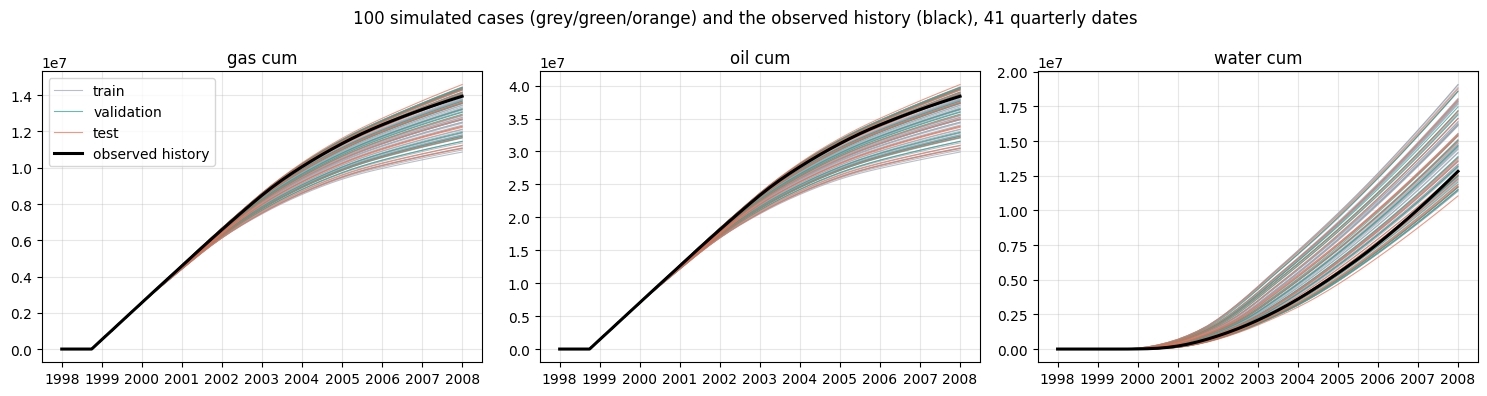

In [9]:
# Picture: do the curves look right? Cumulative production of all 100 cases against the observed history.
colors = {"train": "#9aa5b1", "validation": "#2a9d8f", "test": "#e76f51"}
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, (qi, q) in zip(ax, enumerate(QTY)):
    for sp, col in colors.items():
        ids = cases.loc[cases.split == sp, "case_id"].to_numpy() - 1
        for n, i in enumerate(ids):
            a.plot(history.date, Y[i, :, qi], color=col, lw=0.8, alpha=0.7, label=sp if n == 0 else None)
    a.plot(history.date, y_hist[:, qi], color="black", lw=2.2, label="observed history")
    a.set_title(q.replace("_", " "))
    a.grid(alpha=0.3)
ax[0].legend()
fig.suptitle("100 simulated cases (grey/green/orange) and the observed history (black), 41 quarterly dates")
fig.tight_layout()
plt.show()

## 4. Forecast template (file `09`)

We do not fill the template here. We only prepare the **date axis** for the forecast.

Known issues in the file: dates are **text** (`04/01/2008`, month first), one date is a real datetime, and tab `Case 1` stops at 01/01/2018 (40 rows) while tabs `Case 2`-`Case 10` run to 01/01/2028 (80 rows). We build one clean list of 80 dates.

In [10]:
F09 = DATA / "09 Template Deliverable.xlsx"

def parse_template_date(v):
    return pd.to_datetime(v, format="%m/%d/%Y") if isinstance(v, str) else pd.Timestamp(v)

tmpl = {}
for s in pd.ExcelFile(F09).sheet_names:
    d = pd.read_excel(F09, sheet_name=s)
    d["Date"] = d["Date"].map(parse_template_date)
    tmpl[s] = d

lengths = {s: len(d) for s, d in tmpl.items()}
print("rows per tab:", lengths)
full = tmpl["Case 2"]["Date"]
check("template: tabs Case 2-10 hold the same 80 dates",
      all(tmpl[f"Case {i}"]["Date"].equals(full) for i in range(2, 11)) and len(full) == 80)
check("template: Case 1 dates are the first 40 of those 80", tmpl["Case 1"]["Date"].equals(full.iloc[:40].reset_index(drop=True)))
check("template: dates are quarterly (day 1; months 1, 4, 7, 10) from 2008-04-01 to 2028-01-01",
      full.iloc[0] == pd.Timestamp("2008-04-01") and full.iloc[-1] == pd.Timestamp("2028-01-01")
      and (full.dt.day == 1).all() and set(full.dt.month) == {1, 4, 7, 10})
print("template columns:", list(tmpl["Case 2"].columns))

forecast_dates = pd.DataFrame({"step": np.arange(1, 81), "date": full.to_numpy()})
forecast_dates["t_days"] = (forecast_dates.date - HIST_START).dt.days.astype(float)
forecast_dates["years_after_history"] = (forecast_dates.date - pd.Timestamp("2008-01-01")).dt.days / 365.25
save_csv(forecast_dates, OUT / "forecast_dates.csv")
forecast_dates.iloc[[0, 1, 39, 79]]

rows per tab: {'Case 1': 40, 'Case 2': 80, 'Case 3': 80, 'Case 4': 80, 'Case 5': 80, 'Case 6': 80, 'Case 7': 80, 'Case 8': 80, 'Case 9': 80, 'Case 10': 80}
template columns: ['Date', 'Gas production cumulative [MSCF]', 'Oil production cumulative [STB]', 'Water production cumulative [STB]']


,step,date,t_days,years_after_history
0,1,2008-04-01,"3,743",0.249144
1,2,2008-07-01,"3,834",0.498289
39,40,2018-01-01,"7,305",10.0014
79,80,2028-01-01,"10,957",20


## 5. Grid of the 100 cases (files `03`-`08`)

Each sheet has 90,365 rows (one per cell) and 29 columns. Reading one sheet takes about 20 s, and the six files hold 100 sheets. The raw data as one array would be 100 x 90,365 x 29 x 8 bytes = **2.1 GB**.

**What we do**

| # | Step | Why |
|---|---|---|
| 1 | Read the 100 sheets once, in parallel | about 30 min one by one, about 15 min with 6 workers |
| 2 | Give every column a short name (`PORO`, `porv`, ...). Fix the header typo ` Connateg  Gas Saturation (SGL)` | The 29 headers are long and inconsistent |
| 3 | Compare every column of every case with case 1, and find which columns change | Until now only 3 cases were checked. Now we check all 100 |
| 4 | Keep the **unchanged** columns once, in a template table (`-999.25` becomes `NaN`, plus an `active` flag) | They are the same in every case |
| 5 | Keep the **changing** columns per case, for **active cells only** | This is the only new information. About 100 MB instead of 2.1 GB |
| 6 | Add a few summary numbers per case (total pore volume, mean permeability, ...) | Option for the proxy, and a check that the grid adds nothing beyond the 4 parameters |
| 7 | A helper that puts a cell vector back into a 3D cube (31 x 55 x 53) | Needed for maps, and for a CNN if we ever want one |

In [11]:
REF_PATH = CACHE / "ref_case1_raw.npz"
V_PATH = OUT / "grid_varying_cells.npy"
ACTIVE_PATH = OUT / "grid_active_cell_ids.npy"
CATALOG_PATH = CACHE / "grid_column_catalog.csv"     # cache copies: the notebook reads these ...
GRIDCHK_PATH = CACHE / "grid_case_checks.csv"        # ... and rewrites the copies in data_after_engineering/ on every run

have_cache = all(p.exists() for p in [REF_PATH, V_PATH, ACTIVE_PATH, CATALOG_PATH, GRIDCHK_PATH])

if REBUILD_GRID or not have_cache:
    t0 = time.time()
    # 1. Reference case (case 1), kept as raw numbers. Workers compare every case with it.
    f1, s1 = case_to_file[1]
    header, ref = gl.read_sheet(f1, s1)
    np.savez(REF_PATH, raw=ref)
    print(f"reference case read in {time.time() - t0:.0f} s; shape {ref.shape}")

    # 2. All 100 cases in parallel
    jobs = [(cid, str(f), s, str(REF_PATH)) for cid, (f, s) in sorted(case_to_file.items())]
    results = {}
    with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
        futs = {ex.submit(gl.process_case, j): j[0] for j in jobs}
        for n, fut in enumerate(as_completed(futs), 1):
            r = fut.result()
            results[r["case_id"]] = r
            if n % 10 == 0:
                print(f"  {n:3d}/100 cases done, {time.time() - t0:5.0f} s")
    print(f"all cases read in {time.time() - t0:.0f} s")

    ids = sorted(results)
    max_diff = np.max([results[c]["max_diff"] for c in ids], axis=0)          # per column, over all cases
    ref_active = ref[:, gl.SHORT_NAMES.index("porv")] > 0
    V = np.stack([results[c]["varying"] for c in ids])                         # (100, n_active, 6)
    np.save(V_PATH, V)
    np.save(ACTIVE_PATH, np.flatnonzero(ref_active))

    group = (["grid"] * 6) + (["static"] * 17) + (["dynamic"] * 6)
    catalog = pd.DataFrame({"short": gl.SHORT_NAMES, "raw_header": [str(h) for h in header],
                            "group": group, "max_abs_diff_over_cases": max_diff})
    catalog["varies_by_case"] = catalog.max_abs_diff_over_cases > 0
    save_csv(catalog, CATALOG_PATH)
    save_csv(pd.DataFrame({"case_id": ids, "n_active": [results[c]["n_active"] for c in ids],
                           "same_active_mask_as_case1": [results[c]["same_active_mask"] for c in ids]}), GRIDCHK_PATH)
    del results
else:
    print("using cached grid files (set REBUILD_GRID = True to read the sheets again)")

ref = np.load(REF_PATH)["raw"]
V = np.load(V_PATH)
active_ids = np.load(ACTIVE_PATH)
catalog = pd.read_csv(CATALOG_PATH, float_precision="round_trip")
grid_chk = pd.read_csv(GRIDCHK_PATH, float_precision="round_trip")
save_csv(catalog, OUT / "grid_column_catalog.csv")     # rewritten on every run, so a damaged copy
save_csv(grid_chk, OUT / "grid_case_checks.csv")       # (for example saved by Excel) is repaired
print("varying array (case, active cell, column):", V.shape, V.dtype, f"| {V.nbytes / 1e6:.0f} MB")
catalog

reference case read in 23 s; shape (90365, 29)
   10/100 cases done,   130 s
   20/100 cases done,   233 s
   30/100 cases done,   287 s
   40/100 cases done,   393 s
   50/100 cases done,   497 s
   60/100 cases done,   554 s
   70/100 cases done,   662 s
   80/100 cases done,   768 s
   90/100 cases done,   830 s
  100/100 cases done,   914 s
all cases read in 914 s
varying array (case, active cell, column): (100, 42512, 6) float32 | 102 MB


,short,raw_header,group,max_abs_diff_over_cases,varies_by_case
0,i,I Index,grid,0,False
1,j,J Index,grid,0,False
2,k,K Index,grid,0,False
3,x,X Coordinate,grid,0,False
4,y,Y Coordinate,grid,0,False
5,z,Z Coordinate,grid,0,False
6,porv,Pore Volume (PORV),static,7.00554e+06,True
7,poro,Porosity (PORO),static,0.075756,True
8,permx,Permeability I (PERMX),static,5.1001,True
9,permy,Permeability J (PERMY),static,5.1001,True


In [12]:
# --- Verify on all 100 cases: which columns change, and is the active-cell mask the same?
varying_cols = catalog.loc[catalog.varies_by_case, "short"].tolist()
print("columns that change between cases:", varying_cols)
check("grid: exactly six columns change between cases (porv, poro, permx, permy, tranx, trany)",
      set(varying_cols) == set(gl.VARYING_COLS), str(varying_cols))
check("grid: the active-cell mask is identical in all 100 cases", grid_chk.same_active_mask_as_case1.all())
check("grid: 42,512 active cells in every case", (grid_chk.n_active == 42512).all(), str(grid_chk.n_active.unique()))
check("grid: PERMY equals PERMX in every active cell of every case",
      float(np.abs(V[:, :, gl.VARYING_COLS.index("permx")] - V[:, :, gl.VARYING_COLS.index("permy")]).max()) == 0.0)
check("grid: no missing values (-999.25) left in the varying array", not (V == NA).any())

# --- Template table: the unchanged columns, once, with NaN for missing values
cells = pd.DataFrame(ref, columns=gl.SHORT_NAMES)
cells["active"] = cells["porv"] > 0
cells = cells.replace(NA, np.nan)
for c in ["i", "j", "k", "fipnum", "pvtnum"]:
    cells[c] = cells[c].astype("Int64")
cells.insert(0, "cell_id", np.arange(len(cells)))
const_cols = catalog.loc[~catalog.varies_by_case, "short"].tolist()
template = cells[["cell_id", "active"] + const_cols]
save_csv(template, OUT / "grid_cells_template.csv")

nI, nJ, nK = int(cells.i.max()), int(cells.j.max()), int(cells.k.max())
check("grid: 53 x 55 x 31 cells, every (I, J, K) exactly once",
      (nI, nJ, nK) == (53, 55, 31) and len(cells) == nI * nJ * nK and not cells.duplicated(["i", "j", "k"]).any())
check("grid: active cells have no missing values in the unchanged columns",
      template.loc[template.active, [c for c in const_cols if c not in ("x", "y", "z")]].notna().all().all())
print(f"template table: {template.shape[0]:,} cells x {template.shape[1]} columns; active {int(template.active.sum()):,} ({template.active.mean():.0%})")
template.iloc[np.r_[0:2, 40000:40002]]

columns that change between cases: ['porv', 'poro', 'permx', 'permy', 'tranx', 'trany']
template table: 90,365 cells x 25 columns; active 42,512 (47%)


,cell_id,active,i,j,k,x,y,z,permz,ntg,tranz,fipnum,pvtnum,swl,swcr,swu,sgl,sgcr,sowcr,pressure,swat,soil,sgas,rs,rv
0,0,False,1,1,31,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,False,2,1,31,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40000,40000,True,39,40,18,"557,728",6.80633e+06,"-8,156.28",0.38346,1,0.153887,2,2,0.27,0.35,1,0,0.1,0.18,"4,462.07",1,0,0,0.3633,0
40001,40001,True,40,40,18,"557,873",6.80631e+06,"-8,181.13",0.482373,1,0.334659,2,2,0.27,0.35,1,0,0.1,0.18,"4,472.75",1,0,0,0.3633,0


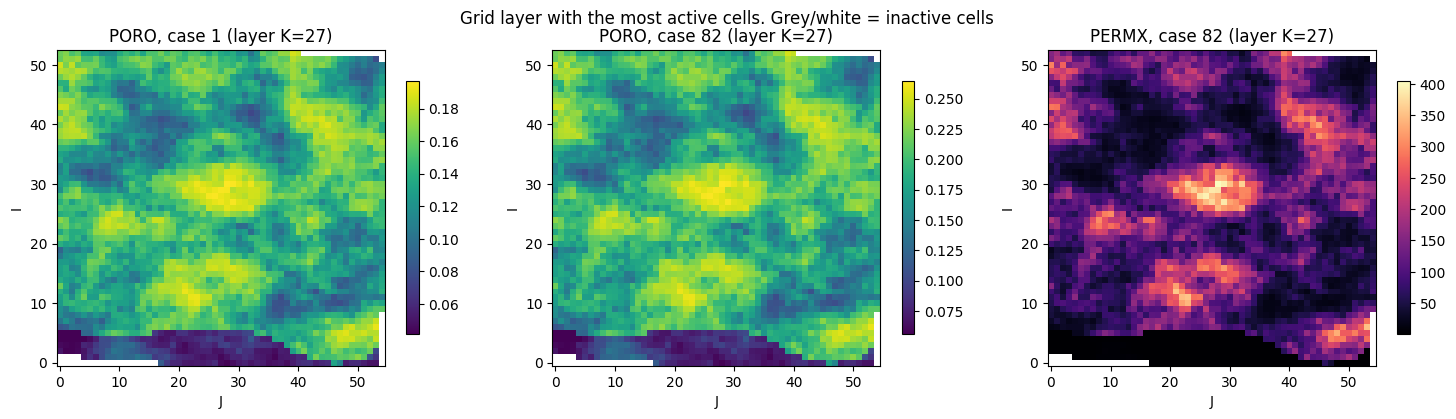

In [13]:
# --- Helpers: rebuild a full cell table for one case, and put a cell vector into a 3-D cube
ci = {c: n for n, c in enumerate(gl.VARYING_COLS)}

def case_cells(case_id):
    """Full table of one case = unchanged columns (all cells) + the six changing columns (active cells)."""
    d = template.copy()
    for c in gl.VARYING_COLS:
        d[c] = np.nan
        d.loc[active_ids, c] = V[case_id - 1, :, ci[c]]
    return d

idx_i, idx_j, idx_k = (cells.i.to_numpy().astype(int) - 1, cells.j.to_numpy().astype(int) - 1, cells.k.to_numpy().astype(int) - 1)

def to_cube(values_active, fill=np.nan):
    """values for the active cells (length 42,512) -> cube[K, J, I], with `fill` in inactive cells."""
    cube = np.full((nK, nJ, nI), fill, dtype=np.float32)
    cube[idx_k[active_ids], idx_j[active_ids], idx_i[active_ids]] = values_active
    return cube

# A round trip, to be sure: case 1 rebuilt from the saved files equals the raw sheet (active cells)
c1_full = case_cells(1)
raw_poro = np.where(ref[:, gl.SHORT_NAMES.index("poro")] == NA, np.nan, ref[:, gl.SHORT_NAMES.index("poro")])
check("round trip: rebuilt case 1 PORO equals the raw sheet",
      np.allclose(c1_full["poro"].to_numpy(dtype=float), raw_poro, rtol=1e-6, equal_nan=True))

# Picture: porosity (case 1) and permeability (the case with the largest multiplier), one layer
k_best = int(cells[cells.active].groupby("k").size().idxmax())
big = int(cases.loc[cases.perm_mult.idxmax(), "case_id"])
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, (vec, title, cmap) in zip(ax, [
    (V[0, :, ci["poro"]], "PORO, case 1", "viridis"),
    (V[big - 1, :, ci["poro"]], f"PORO, case {big}", "viridis"),
    (V[big - 1, :, ci["permx"]], f"PERMX, case {big}", "magma")]):
    im = a.imshow(to_cube(vec)[k_best - 1].T, origin="lower", cmap=cmap)
    a.set_title(f"{title} (layer K={k_best})"); a.set_xlabel("J"); a.set_ylabel("I")
    plt.colorbar(im, ax=a, shrink=0.8)
fig.suptitle("Grid layer with the most active cells. Grey/white = inactive cells")
fig.tight_layout(); plt.show()

### 5.1 What exactly changes between cases? (all 100 cases)

Idea: every case is a scaled copy of the base model. So the ratio `case / case 1` should be a constant in each zone, and the constant should equal the ratio of the parameters in `01`. We test this for all 100 cases.

In [14]:
P_, PORO_, PX_, TX_, TY_ = (V[:, :, ci[c]].astype(np.float64) for c in ["porv", "poro", "permx", "tranx", "trany"])
par = cases.set_index("case_id")

# Ratio of each case to case 1, per cell
r_poro = PORO_ / PORO_[0]
r_perm = PX_ / PX_[0]
r_pv_extra = (P_ / P_[0]) / r_poro          # pore-volume change NOT explained by porosity

# Zones: found in the case where the parameter differs most from case 1
c_perm = int(np.argmax(np.abs(np.log(par.perm_mult.to_numpy() / par.perm_mult.iloc[0]))))
c_aq = int(np.argmax(np.abs(np.log(par.aquifer_pv.to_numpy() / par.aquifer_pv.iloc[0]))))
zone_perm = np.abs(r_perm[c_perm] - 1) > 1e-4
zone_aq = np.abs(r_pv_extra[c_aq] - 1) > 1e-4
print(f"permeability zone: {zone_perm.sum():,} active cells | aquifer zone: {zone_aq.sum():,} active cells")

k_act, i_act = idx_k[active_ids] + 1, idx_i[active_ids] + 1
print(f"permeability zone: layers K = {int(k_act[zone_perm].min())} to {int(k_act[zone_perm].max())} | aquifer zone: I = {int(i_act[zone_aq].min())} to {int(i_act[zone_aq].max())}")

def rel_dev(obs, exp):
    return float(np.max(np.abs(obs / exp - 1)))

exp_poro = (par.poro_mult / par.poro_mult.iloc[0]).to_numpy()[:, None] * np.ones_like(r_poro)
exp_perm = np.where(zone_perm[None, :], (par.perm_mult / par.perm_mult.iloc[0]).to_numpy()[:, None], 1.0)
exp_aq = np.where(zone_aq[None, :], (par.aquifer_pv / par.aquifer_pv.iloc[0]).to_numpy()[:, None], 1.0)

summary = pd.DataFrame([
    {"parameter (01)": "poro_mult",  "grid column": "PORO (PORV follows)", "cells it acts on": int(len(active_ids)),
     "max relative deviation, all 100 cases": rel_dev(r_poro, exp_poro)},
    {"parameter (01)": "perm_mult",  "grid column": "PERMX and PERMY",     "cells it acts on": int(zone_perm.sum()),
     "max relative deviation, all 100 cases": rel_dev(r_perm, exp_perm)},
    {"parameter (01)": "aquifer_pv", "grid column": "PORV (extra scaling)", "cells it acts on": int(zone_aq.sum()),
     "max relative deviation, all 100 cases": rel_dev(r_pv_extra, exp_aq)},
])
print(summary.to_string(index=False))
check("grid: porosity, permeability and aquifer changes equal the ratios in 01 (all 100 cases, tolerance 1e-4)",
      (summary["max relative deviation, all 100 cases"] < 1e-4).all())

permeability zone: 11,575 active cells | aquifer zone: 2,286 active cells
permeability zone: layers K = 13 to 31 | aquifer zone: I = 51 to 53
parameter (01)          grid column  cells it acts on  max relative deviation, all 100 cases
     poro_mult  PORO (PORV follows)             42512                            2.83465e-05
     perm_mult      PERMX and PERMY             11575                            1.95237e-05
    aquifer_pv PORV (extra scaling)              2286                             2.8312e-05


In [15]:
# --- TRANX / TRANY: is anything left after the permeability change is accounted for?
# Transmissibility is a flow capacity between two neighbouring cells. If it scaled exactly with
# permeability, ratio(case / case 1) divided by the permeability ratio would be 1 in every cell.
fr = (par.fault_trans / par.fault_trans.iloc[0]).to_numpy()
pr = (par.perm_mult / par.perm_mult.iloc[0]).to_numpy()
rows = []
for name, T in [("TRANX", TX_), ("TRANY", TY_)]:
    with np.errstate(divide="ignore", invalid="ignore"):
        res = (T / T[0][None, :]) / np.where(zone_perm[None, :], pr[:, None], 1.0)     # residual ratio
    ok0 = T[0][None, :] > 0                                                              # cells with a flow link in case 1
    off = (np.abs(np.nan_to_num(res, nan=1.0) - 1) > 1e-3) & ok0                         # cells that deviate by more than 0.1%
    big_dev = (np.abs(np.nan_to_num(res, nan=1.0) - 1) > 0.10) & ok0                     # ... by more than 10%
    # cells whose residual equals the FAULT ratio (within 3%), tested on cases where the fault ratio differs from 1 by >15%
    sel = np.abs(fr - 1) > 0.15
    fault_like = (np.abs(res / fr[:, None] - 1) < 0.03) & ok0
    rows.append({
        "column": name,
        "cells deviating >0.1% from the permeability rule (per case, min-max)": f"{off[1:].sum(1).min()} - {off[1:].sum(1).max()}",
        "cells deviating >10% (per case, max)": int(big_dev[1:].sum(1).max()),
        "median |deviation| in the deviating cells": float(np.nanmedian(np.abs(res[off] - 1))),
        "cells that follow the FAULT ratio (per case, max)": int(fault_like[sel].sum(1).max()),
        "cells that follow the fault ratio in >80% of cases": int((fault_like[sel].mean(0) > 0.8).sum()),
    })
tran_probe = pd.DataFrame(rows).set_index("column").T
tran_probe

column,TRANX,TRANY
"cells deviating >0.1% from the permeability rule (per case, min-max)",155 - 1295,275 - 767
"cells deviating >10% (per case, max)",14,122
median |deviation| in the deviating cells,0.0038873,0.00473101
"cells that follow the FAULT ratio (per case, max)",3,113
cells that follow the fault ratio in >80% of cases,0,0


**What the two tables show (all 100 cases)**

* Porosity, permeability and aquifer changes match the ratios in `01` to within 3e-5. This small gap comes from the source file, which stores porosity with about 5 decimals. The float32 storage adds only 6e-8. So the grid is, cell by cell, a scaled copy of case 1. **Verified for all 100 cases.**
* The permeability multiplier acts on the cells of layers K = 13 to 31 that carry the zone (11,575 active cells). The aquifer multiplier acts on the 2,286 active cells at the east edge (I = 51 to 53). The porosity multiplier acts on every active cell.
* `TRANX` and `TRANY` follow the permeability change closely. Per case, 155 to 1,295 cells (`TRANX`) and 275 to 767 cells (`TRANY`) deviate by a small amount (median about 0.4%). Up to 14 (`TRANX`) and 122 (`TRANY`) cells deviate by more than 10%. This looks like rounding or averaging between neighbour cells. *Inferred, not checked with a reservoir engineer.*
* **No cell follows the fault transmissibility ratio.** At most 3 (`TRANX`) or 113 (`TRANY`) cells match it in a single case, and no cell matches it in more than 80% of the cases. So the fault transmissibility is **not visible in the grid**. It is probably applied as a multiplier on the fault inside the simulator (*inferred*). This is a reason to keep `fault_trans` as a direct input of the proxy.

In [16]:
# --- Per-case summary numbers from the grid (option for the proxy; also shows how redundant the grid is)
feat = pd.DataFrame({
    "case_id": np.arange(1, 101),
    "total_pv": P_.sum(1),
    "aquifer_pv_grid": P_[:, zone_aq].sum(1),
    "reservoir_pv": P_[:, ~zone_aq].sum(1),
    "mean_poro": PORO_.mean(1),
    "mean_permx": PX_.mean(1),
    "mean_permx_zone": PX_[:, zone_perm].mean(1),
    "mean_tranx": TX_.mean(1),
    "mean_trany": TY_.mean(1),
})
save_csv(feat, OUT / "grid_case_features.csv")

both = cases.merge(feat, on="case_id")
sp = both[PARAMS + [c for c in feat.columns if c != "case_id"]].corr(method="spearman").loc[PARAMS, [c for c in feat.columns if c != "case_id"]]
print("Spearman correlation: parameter (rows) vs grid summary (columns)")
sp

Spearman correlation: parameter (rows) vs grid summary (columns)


,total_pv,aquifer_pv_grid,reservoir_pv,mean_poro,mean_permx,mean_permx_zone,mean_tranx,mean_trany
fault_trans,0.0414641,0.0381878,0.143402,0.143402,-0.0491209,-0.0491209,-0.0491209,-0.0491209
poro_mult,0.423594,0.384326,1,1,-0.0126253,-0.0126253,-0.0126253,-0.0126253
perm_mult,0.143678,0.14447,-0.0126253,-0.0126253,1,1,1,1
aquifer_pv,0.861062,0.881848,-0.0725233,-0.0725233,0.171941,0.171941,0.171941,0.171941


## 5.2 Round trip: do the saved files read back exactly?

A file that cannot be read back is useless. We re-read the saved files with a plain reader and compare them with the tables in memory.

In [17]:
rt = pd.read_csv(OUT / "curves_native.csv", parse_dates=["date"], float_precision="round_trip")
num = ["t_days", "gas_cum", "oil_cum", "water_cum", "gas_rate", "oil_rate", "water_rate"]
check("saved curves_native.csv reads back (dates with milliseconds equal; values equal to 15 significant digits)",
      rt.case_id.equals(native.case_id) and rt.date.equals(native.date) and np.allclose(rt[num].to_numpy(), native[num].to_numpy(), rtol=1e-14, atol=0))
rq = pd.read_csv(OUT / "curves_quarterly.csv", parse_dates=["date"], float_precision="round_trip")
check("saved curves_quarterly.csv reads back (values equal to 15 significant digits)",
      rq.date.equals(quarterly.date) and np.allclose(rq[num[1:] + ["gas_rate_avg", "oil_rate_avg", "water_rate_avg"]].to_numpy(),
                                                  quarterly[num[1:] + ["gas_rate_avg", "oil_rate_avg", "water_rate_avg"]].to_numpy(),
                                                  rtol=1e-14, atol=0, equal_nan=True))
z = np.load(OUT / "curves_quarterly_cum.npz", allow_pickle=False)          # must work without pickle
check("curves_quarterly_cum.npz loads without pickle and keeps its values",
      np.array_equal(z["Y"], Y) and np.array_equal(z["y_hist"], y_hist) and list(z["dates"][:2]) == ["1998-01-01", "1998-04-01"])
rc = pd.read_csv(OUT / "cases.csv", float_precision="round_trip")
check("saved cases.csv reads back (parameters equal to 15 significant digits)", np.allclose(rc[PARAMS].to_numpy(), cases[PARAMS].to_numpy(), rtol=1e-14, atol=0) and rc.split.equals(cases.split))
rv = np.load(V_PATH, allow_pickle=False)
check("grid_varying_cells.npy reads back identical", np.array_equal(rv, V))
import re
too_long = {}
for f in sorted(OUT.glob("*.csv")):
    n = 0
    for line in open(f, encoding="utf-8"):
        for tok in line.strip().split(","):
            if re.fullmatch(r"-?\d*\.?\d+(e[-+]?\d+)?", tok, re.I):
                if len(re.sub(r"^0*\.?0*", "", tok.lower().split("e")[0].replace(".", "").replace("-", ""))) > 15:
                    n += 1
    if n:
        too_long[f.name] = n
check("no CSV number has more than 15 significant digits (safe for Excel)", not too_long, str(too_long))
print("all saved files read back correctly")

all saved files read back correctly


## 6. Final checks and the list of outputs

In [18]:
chk = pd.DataFrame(CHECKS)
print(f"{int(chk.ok.sum())} of {len(chk)} checks passed\n")
chk[["check", "ok", "detail"]]

38 of 38 checks passed



,check,ok,detail
0,"01: 100 cases, ids 1..100, no duplicates",True,
1,01: no missing parameter values,True,
2,03-08: sheets cover cases 1..100 exactly once,True,
3,split sizes are 70 / 15 / 15,True,"{'train': 70, 'validation': 15, 'test': 15}"
4,"split follows case-id ranges (train 1-70, vali...",True,
5,validation/test parameters are at most 5% of t...,True,max 0.032
6,02: the six tabs have the same dates,True,
7,02: the six tabs have the same columns,True,
8,02: 100 case columns + RAMP_History,True,
9,02: the empty-cell pattern is the same in all ...,True,


In [19]:
descr = {
    "cases.csv":                    "100 rows. case_id, split, cv_fold, the 4 parameters and scaled copies (*_s)",
    "param_bounds.csv":             "min and max of each parameter in the train cases (used for scaling)",
    "history_observed.csv":         "41 rows. Observed field history: cumulative, reported rate, average rate, water injection",
    "curves_native.csv":            "all simulator time steps of all cases (long format, about 17k rows)",
    "curves_quarterly.csv":         "100 cases x 41 quarterly dates, same dates as the history (4,100 rows)",
    "curves_quarterly_cum.npz":     "arrays: Y (100, 41, 3) cumulative gas/oil/water, y_hist (41, 3), case_ids, dates, t_days",
    "forecast_dates.csv":           "the 80 quarterly forecast dates of the template (2008-04-01 to 2028-01-01)",
    "grid_column_catalog.csv":      "the 29 grid columns: short name, raw header, group, whether it changes between cases",
    "grid_case_checks.csv":         "per case: active-cell count and mask check against case 1",
    "grid_cells_template.csv":      "90,365 cells: unchanged columns once (NaN for missing), plus the active flag",
    "grid_varying_cells.npy":       "float32 array (100 cases, 42,512 active cells, 6 columns: porv, poro, permx, permy, tranx, trany)",
    "grid_active_cell_ids.npy":     "row numbers (cell_id) of the 42,512 active cells in the template",
    "grid_case_features.csv":       "per case: total pore volume, mean porosity, mean permeability, ...",
}
rows = []
for name, text in descr.items():
    p = OUT / name
    rows.append({"file": name, "size": f"{p.stat().st_size / 1e6:,.2f} MB" if p.exists() else "MISSING", "content": text})
manifest = pd.DataFrame(rows)
assert (manifest["size"] != "MISSING").all()
save_csv(manifest, OUT / "MANIFEST.csv")
manifest

,file,size,content
0,cases.csv,0.02 MB,"100 rows. case_id, split, cv_fold, the 4 param..."
1,param_bounds.csv,0.00 MB,min and max of each parameter in the train cas...
2,history_observed.csv,0.01 MB,"41 rows. Observed field history: cumulative, r..."
3,curves_native.csv,2.07 MB,all simulator time steps of all cases (long fo...
4,curves_quarterly.csv,0.61 MB,"100 cases x 41 quarterly dates, same dates as ..."
5,curves_quarterly_cum.npz,0.10 MB,"arrays: Y (100, 41, 3) cumulative gas/oil/wate..."
6,forecast_dates.csv,0.00 MB,the 80 quarterly forecast dates of the templat...
7,grid_column_catalog.csv,0.00 MB,"the 29 grid columns: short name, raw header, g..."
8,grid_case_checks.csv,0.00 MB,per case: active-cell count and mask check aga...
9,grid_cells_template.csv,10.72 MB,"90,365 cells: unchanged columns once (NaN for ..."


## 7. Decisions made here (so the next notebooks do not redo them)

* **Split.** The organiser's split is kept: train 1-70, validation 71-85, test 86-100. `cv_fold` is an optional extra for the 85 non-test cases. Test cases stay locked until the final score.
* **Time axis.** `t_days` = days since 1998-01-01. Two tables: `curves_native` (all steps) and `curves_quarterly` (the 41 dates that every case and the history share).
* **Rates.** Use cumulative values for matching. Use the `*_rate_avg` columns if you need a rate. The reported rates follow different conventions in history and cases.
* **Gas.** Gas is a fixed multiple of oil in this data, so it needs no model of its own (see the ratio printed in section 3).
* **Grid.** Kept as one template table + one array of the six changing columns. The grid carries the same information as the 4 parameters in `01` (section 5.1), so the first proxy should use the 4 parameters only. `grid_case_features.csv` is available for an experiment.
* **Fault transmissibility** is not visible in any grid cell (section 5.1). Keep it as a direct input.
* **Parameter ranges.** Five parameter values of validation and test cases lie slightly outside the train range (at most 3% of the range; mostly the permeability multiplier, plus one fault transmissibility value in case 82). Expect a little extrapolation for cases 75, 82, 87 and 98.
* **No scaling of the outputs** (curves) here. Scaling or PCA of the curves belongs to the modelling notebook, fitted on train cases only.